In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from astropy.io import fits
from astropy.time import Time
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

In [2]:
# Adjust path if your csv is stored in a subfolder
csv_path = r"data\trainingdata_train.csv"
df = pd.read_csv(csv_path)

print(f"Dataset Shape: {df.shape}")
print("\nMissing values per feature:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head()

Dataset Shape: (2782, 22)

Missing values per feature:
peak_signal               31
peak_to_baseline_ratio    31
baseline_mean             31
baseline_std              31
pre_flare_slope           12
skewness                  12
kurtosis                  12
dtype: int64


,goes_class,goes_class_letter,lc_date,event_start,event_peak,event_end,peak_counts,peak_signal,peak_signal_max,signal_mean,...,decay_time_sec,fwhm_sec,fluence,peak_to_baseline_ratio,baseline_mean,baseline_std,pre_flare_slope,post_peak_slope,skewness,kurtosis
0,M1.1,M,20240202,2024-02-02 02:52:00,2024-02-02 03:01:00,2024-02-02 03:05:00,848.0,166.359348,7.370195,2.766381,...,225.0,210.0,170702.688896,57.240640,14.814649,5.008347,1.017054,-2.948790,0.797797,-0.827141
1,C3.2,C,20240202,2024-02-02 05:20:00,2024-02-02 05:30:00,2024-02-02 05:38:00,170.0,1.544305,1.121524,0.402163,...,459.0,546.0,49726.180039,5.734771,29.643727,90.886374,0.218574,-0.226456,0.200806,-1.334487
2,C1.7,C,20240202,2024-02-02 08:14:00,2024-02-02 08:19:00,2024-02-02 08:25:00,74.0,2.148117,0.961314,0.526010,...,328.0,644.0,10244.994332,2.917745,25.362051,22.642129,0.086167,-0.047424,0.278182,-0.081162
3,C5.6,C,20240202,2024-02-02 10:48:00,2024-02-02 10:57:00,2024-02-02 11:03:00,349.0,29.593697,7.029498,2.461135,...,305.0,336.0,80237.394746,9.776477,35.697933,10.586783,0.406963,-0.601648,0.582240,-1.045101
4,C6.5,C,20240202,2024-02-02 11:16:00,2024-02-02 11:35:00,2024-02-02 12:02:00,423.0,14.077970,4.204879,2.457721,...,1655.0,2324.0,627850.000304,10.183750,41.536762,27.096466,0.309977,-0.121897,-0.401874,-0.669424


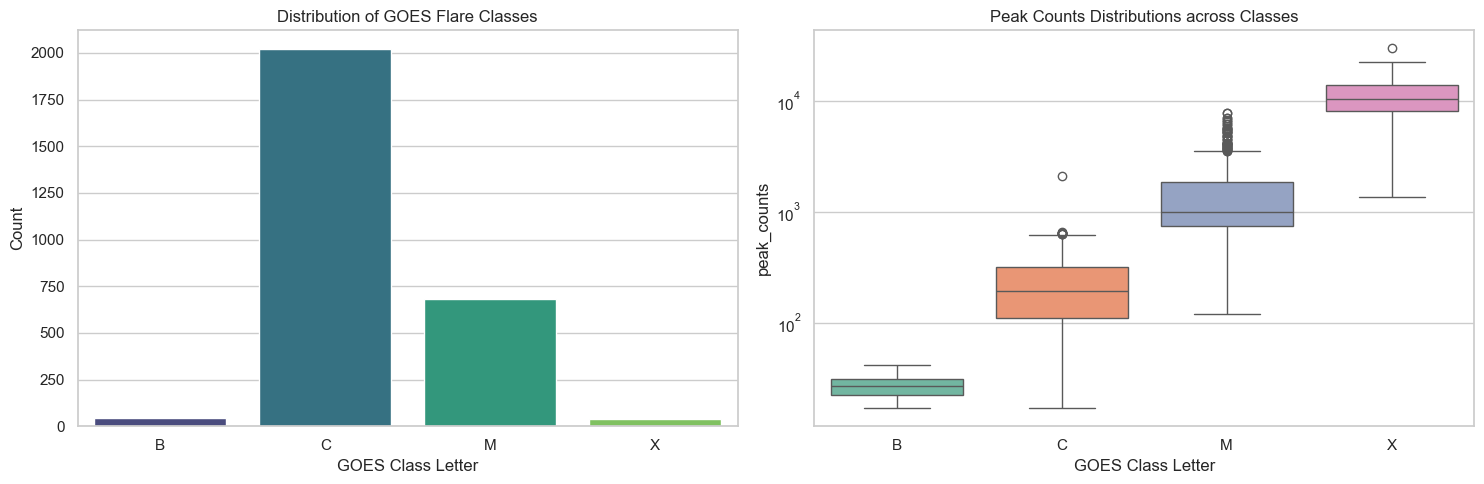

Exact Class Frequencies:
goes_class_letter
C    2020
M     683
B      42
X      37
Name: count, dtype: int64


In [3]:
# Set up a visualization canvas
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Target Label Distribution
sns.countplot(data=df, x='goes_class_letter', order=['B', 'C', 'M', 'X'], ax=axes[0], palette='viridis')
axes[0].set_title("Distribution of GOES Flare Classes")
axes[0].set_xlabel("GOES Class Letter")
axes[0].set_ylabel("Count")

# 2. Key Feature Distribution vs Target Class (Log-scaled Peak Counts)
sns.boxplot(data=df, x='goes_class_letter', y='peak_counts', order=['B', 'C', 'M', 'X'], ax=axes[1], palette='Set2')
axes[1].set_yscale('log')
axes[1].set_title('Peak Counts Distributions across Classes')
axes[1].set_xlabel("GOES Class Letter")

plt.tight_layout()
plt.show()

print("Exact Class Frequencies:")
print(df['goes_class_letter'].value_counts())

In [4]:
# Identify training features (excluding metadata/targets)
feature_cols = [
    'peak_counts', 'peak_signal', 'peak_signal_max', 'signal_mean', 
    'duration_sec', 'rise_time_sec', 'decay_time_sec', 'fwhm_sec', 
    'fluence', 'peak_to_baseline_ratio', 'baseline_mean', 'baseline_std', 
    'pre_flare_slope', 'post_peak_slope', 'skewness', 'kurtosis'
]

X = df[feature_cols]
y = df['goes_class_letter']

# Stratified split ensures training and test hold equal class representation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Pipeline embeds median imputation and an imbalance-aware Random Forest Classifier
flare_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(n_estimators=150, random_state=42, class_weight='balanced'))
])

# Train the model
flare_pipeline.fit(X_train, y_train)
print("Pipeline trained successfully.")

Pipeline trained successfully.


Classification Report:

              precision    recall  f1-score   support

           B       0.67      0.75      0.71         8
           C       0.98      0.98      0.98       405
           M       0.95      0.96      0.96       137
           X       1.00      0.86      0.92         7

    accuracy                           0.97       557
   macro avg       0.90      0.89      0.89       557
weighted avg       0.97      0.97      0.97       557



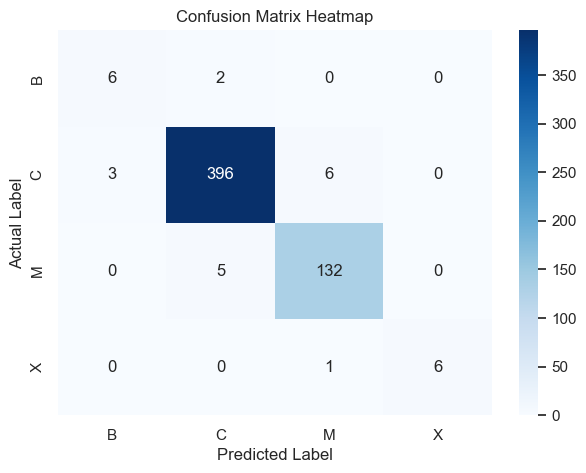

In [5]:
# Predictions
y_pred = flare_pipeline.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred, labels=['B', 'C', 'M', 'X'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['B', 'C', 'M', 'X'], yticklabels=['B', 'C', 'M', 'X'])
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

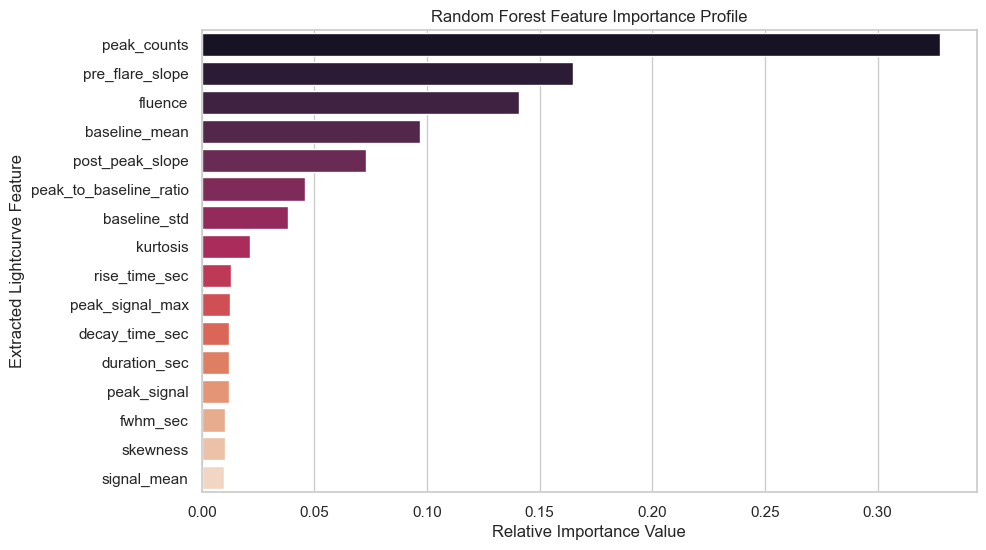

In [6]:
# Retrieve feature importances from trained model
importances = flare_pipeline.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(feature_cols)[indices], palette='rocket')
plt.title('Random Forest Feature Importance Profile')
plt.xlabel('Relative Importance Value')
plt.ylabel('Extracted Lightcurve Feature')
plt.show()

### Inference workflow

In [7]:
# Parameters aligned with data generator
LONG_WINDOW_MIN   = 180
SHORT_WINDOW_MIN  = 3
PRE_CONTEXT_MIN   = 30
MJD_UNIX_OFFSET   = 40587

def mjd_seconds_to_utc(time_col: np.ndarray) -> pd.DatetimeIndex:
    mjd = MJD_UNIX_OFFSET + time_col / 86400.0
    t = Time(mjd, format="mjd", scale="utc")
    return pd.DatetimeIndex(t.to_datetime(timezone=None))

def load_lc(filepath: str) -> pd.DataFrame:
    with fits.open(filepath) as hdul:
        data   = hdul[1].data
        time_r = data["TIME"].astype(np.float64)
        counts = data["COUNTS"].astype(np.float64)
    utc = mjd_seconds_to_utc(time_r)
    df  = pd.DataFrame({"utc": utc, "counts": counts}).set_index("utc").sort_index()
    df["counts"] = df["counts"].ffill().bfill()
    return df

def add_dual_window(df: pd.DataFrame) -> pd.DataFrame:
    long_w  = f"{LONG_WINDOW_MIN}min"
    short_w = f"{SHORT_WINDOW_MIN}min"
    df["long_mean"]  = df["counts"].rolling(long_w,  min_periods=60,  center=False).mean()
    df["long_std"]   = df["counts"].rolling(long_w,  min_periods=60,  center=False).std().clip(lower=1.0)
    df["short_mean"] = df["counts"].rolling(short_w, min_periods=10,  center=False).mean()
    df["signal"]     = (df["short_mean"] - df["long_mean"]) / df["long_std"]
    return df

def fwhm(series: pd.Series) -> float:
    peak = series.max()
    half = peak / 2.0
    above = series[series >= half]
    if len(above) < 2: return float("nan")
    return (above.index[-1] - above.index[0]).total_seconds()

def linear_slope(series: pd.Series) -> float:
    if len(series) < 3: return float("nan")
    t = np.array([(ts - series.index[0]).total_seconds() for ts in series.index])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        coeffs = np.polyfit(t, series.values, 1)
    return coeffs[0]

def extract_single_flare_features(df_full: pd.DataFrame, t_start: pd.Timestamp, t_end: pd.Timestamp) -> dict | None:
    flare = df_full.loc[t_start:t_end, "counts"]
    if len(flare) < 5: return None

    pre_start = t_start - pd.Timedelta(minutes=PRE_CONTEXT_MIN)
    baseline_window = df_full.loc[pre_start:t_start, ["long_mean", "long_std"]]
    baseline_mean = baseline_window["long_mean"].mean()
    baseline_std  = baseline_window["long_std"].mean()

    peak_counts = flare.max()
    peak_time   = flare.idxmax()
    peak_signal = (peak_counts - baseline_mean) / max(baseline_std, 1.0)

    duration_sec = (t_end - t_start).total_seconds()
    rise_time_sec = (peak_time - t_start).total_seconds()
    decay_time_sec = (t_end - peak_time).total_seconds()
    fwhm_sec = fwhm(flare)
    fluence = (flare - baseline_mean).clip(lower=0).sum()
    ptb_ratio = peak_counts / max(baseline_mean, 1.0)

    rise_seg  = df_full.loc[t_start:peak_time, "counts"]
    decay_seg = df_full.loc[peak_time:t_end,   "counts"]
    pre_flare_slope  = linear_slope(rise_seg)
    post_peak_slope  = linear_slope(decay_seg)

    skewness = skew(flare.values)
    kurt     = kurtosis(flare.values)

    signal_in_flare = df_full.loc[t_start:t_end, "signal"]
    peak_signal_max = signal_in_flare.max()
    signal_mean     = signal_in_flare.mean()

    return {
        "peak_counts": peak_counts, "peak_signal": peak_signal, "peak_signal_max": peak_signal_max,
        "signal_mean": signal_mean, "duration_sec": duration_sec, "rise_time_sec": rise_time_sec,
        "decay_time_sec": decay_time_sec, "fwhm_sec": fwhm_sec, "fluence": fluence,
        "peak_to_baseline_ratio": ptb_ratio, "baseline_mean": baseline_mean, "baseline_std": baseline_std,
        "pre_flare_slope": pre_flare_slope, "post_peak_slope": post_peak_slope, "skewness": skewness,
        "kurtosis": kurt
    }

def predict_flare_class(lc_filepath: str, t_start_str: str, t_end_str: str, model_pipeline) -> str:
    """Loads a fresh FITS .lc file, extracts features natively, and runs the classifier."""
    if not os.path.exists(lc_filepath):
        return f"Error: File {lc_filepath} path invalid."
    
    # Process lightcurve properties
    df_lc = load_lc(lc_filepath)
    df_lc = add_dual_window(df_lc)
    
    # Isolate targets
    t_start = pd.to_datetime(t_start_str)
    t_end = pd.to_datetime(t_end_str)
    
    # Vectorize features
    feat_dict = extract_single_flare_features(df_lc, t_start, t_end)
    if feat_dict is None:
        return "Extraction Error: Insufficient observation window context."
        
    # Match schema shape exactly
    feat_df = pd.DataFrame([feat_dict])[feature_cols]
    return model_pipeline.predict(feat_df)[0]

In [8]:
# Deployment verification placeholder:
target_lc = "data/lcfiles_train/AL1_SOLEXS_20240202_SDD2_L1.lc"
prediction = predict_flare_class(target_lc, "2024-02-02 02:52:00", "2024-02-02 03:05:00", flare_pipeline)
print(f"Predicted GOES Class: {prediction}")
print("Operational pipeline compiled and ready.")

Predicted GOES Class: M
Operational pipeline compiled and ready.


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.time import Time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# ── 1. TRAIN THE REAL-TIME ONLY CLASSIFIER ─────────────────────────────────────

def train_realtime_classifier(csv_path: str):
    df = pd.read_csv(csv_path)
    
    # Strictly use features available at the moment of peak detection
    realtime_features = [
        'peak_counts', 'peak_signal', 'baseline_mean', 'baseline_std',
        'peak_to_baseline_ratio', 'pre_flare_slope', 'rise_time_sec'
    ]
    
    X = df[realtime_features]
    y = df['goes_class_letter']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    # Simple median imputation handles cases where rise_time or slope calculation fails
    rt_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
    ])
    
    rt_pipeline.fit(X_train, y_train)
    
    print("=== Real-Time Classifier Evaluation (At-Peak Features Only) ===")
    preds = rt_pipeline.predict(X_test)
    print(classification_report(y_test, preds))
    
    return rt_pipeline, realtime_features


# ── 2. REAL-TIME DETECTOR & STREAM SIMULATOR ──────────────────────────────────

class RealTimeFlareEngine:
    def __init__(self, model_pipeline, feature_names):
        self.model = model_pipeline
        self.feature_names = feature_names
        
        # Hyperparameters for detection
        self.DETECTION_THRESHOLD = 4.0   # Signal Z-score to trigger potential flare
        self.CONFIRMATION_WINDOW = 10     # Seconds signal must stay above threshold (kills noise spikes)
        self.PEAK_DECAY_LOOKBACK = 15     # Seconds counts must trend downward to confirm peak occurred

    def simulate_stream(self, df_lc: pd.DataFrame):
        """
        Simulates row-by-row real-time streaming ingestion of an .lc file.
        Calculates streaming properties without looking forward into the dataframe.
        """
        print("\n[START] Commencing real-time stream simulation...")
        
        # State tracking: "SEARCHING", "RISING"
        state = "SEARCHING"
        
        flare_start_time = None
        current_peak_counts = 0
        current_peak_time = None
        
        # Pre-compute rolling metrics safely using historical windows
        # In a true production script, you'd maintain a circular buffer for these
        df_lc["long_mean"] = df_lc["counts"].rolling("180min", min_periods=60).mean()
        df_lc["long_std"]  = df_lc["counts"].rolling("180min", min_periods=60).std().clip(lower=1.0)
        df_lc["short_mean"] = df_lc["counts"].rolling("3min", min_periods=10).mean()
        df_lc["signal"] = (df_lc["short_mean"] - df_lc["long_mean"]) / df_lc["long_std"]
        
        # Streaming Loop
        for idx in range(len(df_lc)):
            current_time = df_lc.index[idx]
            current_row = df_lc.iloc[idx]
            
            # Skip warm-up periods where baseline calculations aren't ready
            if pd.isna(current_row["signal"]):
                continue
                
            if state == "SEARCHING":
                # Look ahead briefly only for confirmation duration to match streaming lookback
                window = df_lc.iloc[idx : idx + self.CONFIRMATION_WINDOW]
                if len(window) == self.CONFIRMATION_WINDOW and (window["signal"] > self.DETECTION_THRESHOLD).all():
                    state = "RISING"
                    flare_start_time = current_time
                    current_peak_counts = current_row["counts"]
                    current_peak_time = current_time
                    print(f"-> Alert at {current_time}: Solar Flare Detection Triggered!")
                    
            elif state == "RISING":
                # Track maximum intensity reached
                if current_row["counts"] > current_peak_counts:
                    current_peak_counts = current_row["counts"]
                    current_peak_time = current_time
                
                # Check if we have passed the peak (counts drop consistently below peak)
                lookback_window = df_lc.loc[current_peak_time:current_time]
                decay_duration = (current_time - current_peak_time).total_seconds()
                
                if decay_duration >= self.PEAK_DECAY_LOOKBACK:
                    # Peak is confirmed! Calculate instant features up to this second
                    baseline_mean = current_row["long_mean"]
                    baseline_std = current_row["long_std"]
                    peak_signal = (current_peak_counts - baseline_mean) / baseline_std
                    rise_time_sec = (current_peak_time - flare_start_time).total_seconds()
                    ptb_ratio = current_peak_counts / max(baseline_mean, 1.0)
                    
                    # Calculate rise slope via linear fit on the rise segment
                    rise_series = df_lc.loc[flare_start_time:current_peak_time, "counts"]
                    if len(rise_series) >= 3:
                        t_seconds = np.array([(t - rise_series.index[0]).total_seconds() for t in rise_series.index])
                        pre_flare_slope = np.polyfit(t_seconds, rise_series.values, 1)[0]
                    else:
                        pre_flare_slope = 0.0
                        
                    # Bundle into feature payload
                    live_features = pd.DataFrame([{
                        'peak_counts': current_peak_counts,
                        'peak_signal': peak_signal,
                        'baseline_mean': baseline_mean,
                        'baseline_std': baseline_std,
                        'peak_to_baseline_ratio': ptb_ratio,
                        'pre_flare_slope': pre_flare_slope,
                        'rise_time_sec': rise_time_sec
                    }])[self.feature_names]
                    
                    # Classify instantly
                    predicted_class = self.model.predict(live_features)[0]
                    
                    print(f"🥇 Peak Confirmed at {current_peak_time}!")
                    print(f"   [METRICS] Rise Time: {rise_time_sec}s | Peak Counts: {current_peak_counts}")
                    print(f"   [CLASSIFICATION] Predicted GOES Class: {predicted_class}\n")
                    
                    # Reset state machine to look for the next flare
                    state = "SEARCHING"


# ── 3. RUN SIMULATION ──────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Path settings 
    csv_training_data = r"data\trainingdata_train.csv"
    
    # 1. Train the real-time constrained pipeline
    rt_model, feat_columns = train_realtime_classifier(csv_training_data)
    
    # 2. Instantiate Stream Engine
    engine = RealTimeFlareEngine(rt_model, feat_columns)
    
    # 3. Simulate processing on an unseen or raw validation .lc file if available
    # For testing, you can read one of your raw daily data dataframes:
    df_raw = load_lc("data/lcfiles_test/AL1_SOLEXS_20240202_SDD2_L1.lc")
    engine.simulate_stream(df_raw)

=== Real-Time Classifier Evaluation (At-Peak Features Only) ===
              precision    recall  f1-score   support

           B       0.75      0.75      0.75         8
           C       0.98      0.98      0.98       405
           M       0.94      0.96      0.95       137
           X       1.00      0.86      0.92         7

    accuracy                           0.97       557
   macro avg       0.92      0.89      0.90       557
weighted avg       0.97      0.97      0.97       557


[START] Commencing real-time stream simulation...
-> Alert at 2024-02-02 02:59:13: Solar Flare Detection Triggered!
🥇 Peak Confirmed at 2024-02-02 03:01:15!
   [METRICS] Rise Time: 122.0s | Peak Counts: 848.0
   [CLASSIFICATION] Predicted GOES Class: M

-> Alert at 2024-02-02 03:01:31: Solar Flare Detection Triggered!
🥇 Peak Confirmed at 2024-02-02 03:01:43!
   [METRICS] Rise Time: 12.0s | Peak Counts: 806.0
   [CLASSIFICATION] Predicted GOES Class: M

-> Alert at 2024-02-02 03:01:59: Solar Flar

In [11]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_realtime_system(gt_csv_path: str, lc_dir: str, engine, feature_names):
    """
    Runs the RealTimeFlareEngine across the dataset and validates detections
    against the raw ground-truth catalog.
    """
    # 1. Load and parse the raw ground truth file
    print("[INFO] Loading ground truth catalog...")
    gt_df = pd.read_csv(gt_csv_path)
    gt_df.columns = gt_df.columns.str.strip()
    
    for col in ["event_starttime", "event_peaktime", "event_endtime"]:
        gt_df[col] = pd.to_datetime(gt_df[col], format='mixed', dayfirst=True)
    
    # Extract the target GOES letter class mapping
    if 'goes_class_letter' not in gt_df.columns and 'fl_goescls' in gt_df.columns:
        gt_df['goes_class_letter'] = gt_df['fl_goescls'].astype(str).str[0].str.upper()

    # Tracking metrics across the entire stream
    all_gt_matches = []      # True classes for successfully detected flares
    all_pred_matches = []    # Predicted classes for successfully detected flares
    
    total_true_positives = 0
    total_false_positives = 0
    total_false_negatives = 0
    
    # Define a matching tolerance margin (e.g., 5 minutes) around windows
    time_margin = pd.Timedelta(minutes=5)
    
    # 2. Iterate day-by-day based on available .lc files
    lc_files = glob.glob(os.path.join(lc_dir, "*.lc"))
    if not lc_files:
        print(f"[ERROR] No .lc files found in directory: {lc_dir}")
        return

    print(f"[INFO] Beginning stream validation across {len(lc_files)} lightcurve files...\n")
    
    for file_path in lc_files:
        # Extract date from filename: AL1_SOLEXS_YYYYMMDD_SDD2_L1.lc
        filename = os.path.basename(file_path)
        try:
            date_str = filename.split("_")[2]  # YYYYMMDD
        except IndexError:
            continue
            
        # Isolate ground truth events for this specific day
        # Handles both integer formats (20240202) or string interpretations
        day_gt = gt_df[gt_df['lc_date'].astype(str) == str(date_str)].copy()
        
        # Load and prepare the streaming data
        try:
            df_lc = load_lc(file_path)
            df_lc = add_dual_window(df_lc)
        except Exception as e:
            print(f"[SKIP] Failed to parse file {filename}: {e}")
            continue
            
        # ── RUN STREAM ENGINE OVER THE FILE ──────────────────────────────────
        # Custom mini-stream loop to catch outputs programmatically
        state = "SEARCHING"
        flare_start_time = None
        current_peak_counts = 0
        current_peak_time = None
        
        detected_events = [] # Store local detections: (peak_time, pred_class)
        
        for idx in range(len(df_lc)):
            current_time = df_lc.index[idx]
            current_row = df_lc.iloc[idx]
            
            if pd.isna(current_row["signal"]):
                continue
                
            if state == "SEARCHING":
                window = df_lc.iloc[idx : idx + engine.CONFIRMATION_WINDOW]
                if len(window) == engine.CONFIRMATION_WINDOW and (window["signal"] > engine.DETECTION_THRESHOLD).all():
                    state = "RISING"
                    flare_start_time = current_time
                    current_peak_counts = current_row["counts"]
                    current_peak_time = current_time
                    
            elif state == "RISING":
                if current_row["counts"] > current_peak_counts:
                    current_peak_counts = current_row["counts"]
                    current_peak_time = current_time
                
                decay_duration = (current_time - current_peak_time).total_seconds()
                if decay_duration >= engine.PEAK_DECAY_LOOKBACK:
                    # Compile instant features
                    baseline_mean = current_row["long_mean"]
                    baseline_std = current_row["long_std"]
                    peak_signal = (current_peak_counts - baseline_mean) / baseline_std
                    rise_time_sec = (current_peak_time - flare_start_time).total_seconds()
                    ptb_ratio = current_peak_counts / max(baseline_mean, 1.0)
                    
                    rise_series = df_lc.loc[flare_start_time:current_peak_time, "counts"]
                    pre_flare_slope = np.polyfit(np.array([(t - rise_series.index[0]).total_seconds() for t in rise_series.index]), rise_series.values, 1)[0] if len(rise_series) >= 3 else 0.0
                    
                    live_features = pd.DataFrame([{
                        'peak_counts': current_peak_counts, 'peak_signal': peak_signal,
                        'baseline_mean': baseline_mean, 'baseline_std': baseline_std,
                        'peak_to_baseline_ratio': ptb_ratio, 'pre_flare_slope': pre_flare_slope,
                        'rise_time_sec': rise_time_sec
                    }])[feature_names]
                    
                    predicted_class = engine.model.predict(live_features)[0]
                    detected_events.append({"peak_time": current_peak_time, "pred_class": predicted_class})
                    
                    state = "SEARCHING"

        # ── TEMPORAL MATCHING VALIDATION LOGIC ──────────────────────────────
        matched_gt_indices = set()
        
        for detection in detected_events:
            det_time = detection["peak_time"]
            pred_cls = detection["pred_class"]
            
            # Check if this detection hits a ground truth window
            match = day_gt[
                (det_time >= day_gt["event_starttime"] - time_margin) & 
                (det_time <= day_gt["event_endtime"] + time_margin)
            ]
            
            if not match.empty:
                # True Positive signal validation
                gt_idx = match.index[0]
                if gt_idx not in matched_gt_indices:
                    matched_gt_indices.add(gt_idx)
                    total_true_positives += 1
                    
                    actual_cls = match.loc[gt_idx, "goes_class_letter"]
                    all_gt_matches.append(actual_cls)
                    all_pred_matches.append(pred_cls)
            else:
                # Spurious trigger -> False Positive
                total_false_positives += 1
                
        # Any ground truth event missed represents a False Negative
        missed_flares = len(day_gt) - len(matched_gt_indices)
        total_false_negatives += missed_flares

    # 3. CALCULATE & SHOW OPERATIONAL METRICS
    print("\n" + "="*50)
    print("         REAL-TIME SYSTEM EVALUATION METRICS        ")
    print("="*50)
    print(f"Total Ground Truth Flares Processed : {len(gt_df)}")
    print(f"True Positive Detections (Hits)     : {total_true_positives}")
    print(f"False Positive Detections (Alarms)  : {total_false_positives}")
    print(f"False Negative Detections (Misses)  : {total_false_negatives}")
    print("-"*50)
    
    precision = total_true_positives / (total_true_positives + total_false_positives) if (total_true_positives + total_false_positives) > 0 else 0
    recall = total_true_positives / (total_true_positives + total_false_negatives) if (total_true_positives + total_false_negatives) > 0 else 0
    f1_detection = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Signal Detection Precision          : {precision:.4f}")
    print(f"Signal Detection Recall (Sensitivity): {recall:.4f}")
    print(f"Signal Detection F1-Score           : {f1_detection:.4f}")
    print("="*50)
    
    if all_gt_matches:
        print("\n=== GOES Class Classification Report (For True Positives Only) ===")
        print(classification_report(all_gt_matches, all_pred_matches, labels=['B', 'C', 'M', 'X']))
    else:
        print("\n[WARN] No matching events found to run a classification metric assessment.")

# ── RUN THE VALIDATION ────────────────────────────────────────────────────────
# Assumes 'rt_model' and 'feat_columns' variables exist from the previous training run
evaluate_realtime_system(
    gt_csv_path="data/hek_flares.csv", 
    lc_dir="data/lcfiles_train", 
    engine=engine, 
    feature_names=feat_columns
)

[INFO] Loading ground truth catalog...
[INFO] Beginning stream validation across 270 lightcurve files...


         REAL-TIME SYSTEM EVALUATION METRICS        
Total Ground Truth Flares Processed : 3347
True Positive Detections (Hits)     : 908
False Positive Detections (Alarms)  : 717
False Negative Detections (Misses)  : 1875
--------------------------------------------------
Signal Detection Precision          : 0.5588
Signal Detection Recall (Sensitivity): 0.3263
Signal Detection F1-Score           : 0.4120

=== GOES Class Classification Report (For True Positives Only) ===
              precision    recall  f1-score   support

           B       0.00      0.00      0.00         2
           C       0.83      0.99      0.90       509
           M       0.95      0.73      0.82       366
           X       1.00      0.68      0.81        31

    accuracy                           0.87       908
   macro avg       0.69      0.60      0.63       908
weighted avg       0.88      0.87  

In [12]:
evaluate_realtime_system(
    gt_csv_path="data/hek_flares.csv", 
    lc_dir="data/lcfiles_test", 
    engine=engine, 
    feature_names=feat_columns
)

[INFO] Loading ground truth catalog...
[INFO] Beginning stream validation across 60 lightcurve files...


         REAL-TIME SYSTEM EVALUATION METRICS        
Total Ground Truth Flares Processed : 3347
True Positive Detections (Hits)     : 176
False Positive Detections (Alarms)  : 81
False Negative Detections (Misses)  : 388
--------------------------------------------------
Signal Detection Precision          : 0.6848
Signal Detection Recall (Sensitivity): 0.3121
Signal Detection F1-Score           : 0.4287

=== GOES Class Classification Report (For True Positives Only) ===
              precision    recall  f1-score   support

           B       0.00      0.00      0.00         0
           C       0.88      1.00      0.94       130
           M       0.96      0.57      0.72        42
           X       1.00      0.75      0.86         4

    accuracy                           0.89       176
   macro avg       0.71      0.58      0.63       176
weighted avg       0.90      0.89     

update

In [13]:
class OptimizedRealTimeFlareEngine:
    def __init__(self, model_pipeline, feature_names):
        self.model = model_pipeline
        self.feature_names = feature_names
        
        # --- Optimized Hyperparameters ---
        self.DETECTION_THRESHOLD = 2.5    # Lowered from 4.0 to capture smaller/gradual flares
        self.CONFIRMATION_WINDOW = 5      # Shortened from 10 to catch fast-onset events
        self.VELOCITY_THRESHOLD = 1.5     # Minimum positive slope (counts/sec) over short window
        self.PEAK_DECAY_LOOKBACK = 10     # Seconds to confirm peak turnaround
        self.MIN_COUNTS_FLOOR = 15.0      # Ignore telemetry noise when the sun is 'quiet' or occulted

    def simulate_stream(self, df_lc: pd.DataFrame):
        """
        An upgraded, row-by-row streaming simulation tracking both signal variance 
        and raw acceleration (velocity) to optimize precision and recall.
        """
        state = "SEARCHING"
        flare_start_time = None
        current_peak_counts = 0
        current_peak_time = None
        
        # Maintain identical feature pre-calculations
        df_lc["long_mean"] = df_lc["counts"].rolling("180min", min_periods=60).mean()
        df_lc["long_std"]  = df_lc["counts"].rolling("180min", min_periods=60).std().clip(lower=1.0)
        df_lc["short_mean"] = df_lc["counts"].rolling("3min", min_periods=10).mean()
        df_lc["signal"] = (df_lc["short_mean"] - df_lc["long_mean"]) / df_lc["long_std"]
        
        # Calculate instant count velocity (derivative across 3 consecutive readings)
        df_lc["velocity"] = df_lc["counts"].diff(periods=3)
        
        detected_events = []

        for idx in range(len(df_lc)):
            current_time = df_lc.index[idx]
            current_row = df_lc.iloc[idx]
            
            if pd.isna(current_row["signal"]) or pd.isna(current_row["velocity"]):
                continue
                
            # Telemetry Guard: ignore transitions into orbital night or instrumentation blackouts
            if current_row["counts"] < self.MIN_COUNTS_FLOOR:
                if state == "RISING": 
                    state = "SEARCHING" # Reset if data drops out mid-event
                continue
                
            if state == "SEARCHING":
                # Check sliding confirmation block
                window = df_lc.iloc[idx : idx + self.CONFIRMATION_WINDOW]
                
                if len(window) == self.CONFIRMATION_WINDOW:
                    z_pass = (window["signal"] > self.DETECTION_THRESHOLD).all()
                    v_pass = (window["velocity"] > self.VELOCITY_THRESHOLD).any()
                    
                    if z_pass and v_pass:
                        state = "RISING"
                        flare_start_time = current_time
                        current_peak_counts = current_row["counts"]
                        current_peak_time = current_time
                        
            elif state == "RISING":
                # Track the turning point
                if current_row["counts"] > current_peak_counts:
                    current_peak_counts = current_row["counts"]
                    current_peak_time = current_time
                
                decay_duration = (current_time - current_peak_time).total_seconds()
                
                if decay_duration >= self.PEAK_DECAY_LOOKBACK:
                    # Compile feature vectors at peak confirmation
                    baseline_mean = current_row["long_mean"]
                    baseline_std = current_row["long_std"]
                    peak_signal = (current_peak_counts - baseline_mean) / baseline_std
                    rise_time_sec = (current_peak_time - flare_start_time).total_seconds()
                    ptb_ratio = current_peak_counts / max(baseline_mean, 1.0)
                    
                    rise_series = df_lc.loc[flare_start_time:current_peak_time, "counts"]
                    if len(rise_series) >= 3:
                        t_seconds = np.array([(t - rise_series.index[0]).total_seconds() for t in rise_series.index])
                        pre_flare_slope = np.polyfit(t_seconds, rise_series.values, 1)[0]
                    else:
                        pre_flare_slope = 0.0
                        
                    live_features = pd.DataFrame([{
                        'peak_counts': current_peak_counts, 'peak_signal': peak_signal,
                        'baseline_mean': baseline_mean, 'baseline_std': baseline_std,
                        'peak_to_baseline_ratio': ptb_ratio, 'pre_flare_slope': pre_flare_slope,
                        'rise_time_sec': rise_time_sec
                    }])[self.feature_names]
                    
                    predicted_class = self.model.predict(live_features)[0]
                    detected_events.append({"peak_time": current_peak_time, "pred_class": predicted_class})
                    
                    # Reset state engine
                    state = "SEARCHING"
                    
        return detected_events

In [14]:
evaluate_realtime_system(
    gt_csv_path="data/hek_flares.csv", 
    lc_dir="data/lcfiles_train", 
    engine=engine, 
    feature_names=feat_columns)

[INFO] Loading ground truth catalog...
[INFO] Beginning stream validation across 270 lightcurve files...


         REAL-TIME SYSTEM EVALUATION METRICS        
Total Ground Truth Flares Processed : 3347
True Positive Detections (Hits)     : 908
False Positive Detections (Alarms)  : 717
False Negative Detections (Misses)  : 1875
--------------------------------------------------
Signal Detection Precision          : 0.5588
Signal Detection Recall (Sensitivity): 0.3263
Signal Detection F1-Score           : 0.4120

=== GOES Class Classification Report (For True Positives Only) ===
              precision    recall  f1-score   support

           B       0.00      0.00      0.00         2
           C       0.83      0.99      0.90       509
           M       0.95      0.73      0.82       366
           X       1.00      0.68      0.81        31

    accuracy                           0.87       908
   macro avg       0.69      0.60      0.63       908
weighted avg       0.88      0.87  

In [15]:
evaluate_realtime_system(
    gt_csv_path="data/hek_flares.csv", 
    lc_dir="data/lcfiles_test", 
    engine=engine, 
    feature_names=feat_columns
)

[INFO] Loading ground truth catalog...
[INFO] Beginning stream validation across 60 lightcurve files...


         REAL-TIME SYSTEM EVALUATION METRICS        
Total Ground Truth Flares Processed : 3347
True Positive Detections (Hits)     : 176
False Positive Detections (Alarms)  : 81
False Negative Detections (Misses)  : 388
--------------------------------------------------
Signal Detection Precision          : 0.6848
Signal Detection Recall (Sensitivity): 0.3121
Signal Detection F1-Score           : 0.4287

=== GOES Class Classification Report (For True Positives Only) ===
              precision    recall  f1-score   support

           B       0.00      0.00      0.00         0
           C       0.88      1.00      0.94       130
           M       0.96      0.57      0.72        42
           X       1.00      0.75      0.86         4

    accuracy                           0.89       176
   macro avg       0.71      0.58      0.63       176
weighted avg       0.90      0.89     

In [3]:
import pandas as pd
df = pd.read_parquet(r"D:\Obj_detection\BhaAntHack\data\out_builddata\windows_features.parquet")
df.head()


,window_start_time,window_end_time,segment_id,source_file,n_valid,frac_valid,mean,median,std,min,...,mean_ratio_to_bg,max_ratio_to_bg,frac_above_3sigma,frac_above_5sigma,ratio_local_to_longterm_bg,hour_sin,hour_cos,label_binary,label_class,flare_frac_in_window
0,2024-02-02 00:00:00,2024-02-02 00:00:59,0,AL1_SOLEXS_20240202_SDD2_L1.lc,59,0.983333,14.847458,15.0,4.185583,3.0,...,NaN,NaN,0.0,0.0,NaN,0.0,1.0,0,NONE,0.0
1,2024-02-02 00:00:15,2024-02-02 00:01:14,0,AL1_SOLEXS_20240202_SDD2_L1.lc,60,1.000000,14.850000,14.5,4.061301,3.0,...,NaN,NaN,0.0,0.0,NaN,0.0,1.0,0,NONE,0.0
2,2024-02-02 00:00:30,2024-02-02 00:01:29,0,AL1_SOLEXS_20240202_SDD2_L1.lc,60,1.000000,14.916667,14.5,3.560392,6.0,...,NaN,NaN,0.0,0.0,NaN,0.0,1.0,0,NONE,0.0
3,2024-02-02 00:00:45,2024-02-02 00:01:44,0,AL1_SOLEXS_20240202_SDD2_L1.lc,60,1.000000,14.800000,14.5,3.340659,6.0,...,0.977778,1.4,0.0,0.0,NaN,0.0,1.0,0,NONE,0.0
4,2024-02-02 00:01:00,2024-02-02 00:01:59,0,AL1_SOLEXS_20240202_SDD2_L1.lc,60,1.000000,15.050000,15.0,3.528101,8.0,...,0.986667,1.6,0.0,0.0,NaN,0.0,1.0,0,NONE,0.0
